Information Extraction & Semantic Search

## Market Goal
Build **document intelligence systems** used in:
- HR (Resume parsing, ATS)
- Legal (Contract analysis)
- FinTech (Invoices, KYC)
- Healthcare (Clinical notes)

These systems convert **unstructured text into structured, searchable data**.


## Why Information Extraction?

Real-world business data is mostly:
- PDFs
- Emails
- Word documents
- Free text

Machines cannot use raw text.
Transformers help us:
- Extract entities
- Understand meaning
- Search semantically (not by keywords)


## Topics Covered

- Named Entity Recognition (NER)
- Token-level classification
- Sentence embeddings
- Semantic similarity
- Cosine distance


In [1]:
!pip install sentence-transformers


## Named Entity Recognition (NER)

NER identifies and labels entities such as:
- Names
- Organizations
- Skills
- Dates
- Locations
- Monetary values

### Industry Examples
- Resume parsing (skills, experience)
- Invoice processing
- Legal contract entities


## Token-Level Classification

NER is a **token-level task**:
- Each word/token is classified
- Uses BIO tagging (B-ENTITY, I-ENTITY, O)

Transformers handle this naturally due to contextual embeddings.


In [2]:
from transformers import pipeline
import torch


In [3]:
device = 0 if torch.cuda.is_available() else -1
print("Using device:", device)


Using device: 0


In [4]:
ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=device
)

text = """
Muhammad Ali has 5 years of experience in Python, Machine Learning,
and Deep Learning. He worked at Systems Limited from 2019 to 2024.
"""

entities = ner_pipeline(text)

for ent in entities:
    print(ent)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


{'entity_group': 'PER', 'score': np.float32(0.9995668), 'word': 'Muhammad Ali', 'start': 1, 'end': 13}
{'entity_group': 'MISC', 'score': np.float32(0.9377907), 'word': 'Python', 'start': 43, 'end': 49}
{'entity_group': 'ORG', 'score': np.float32(0.8609586), 'word': 'Machine Learning', 'start': 51, 'end': 67}
{'entity_group': 'ORG', 'score': np.float32(0.9737618), 'word': 'Deep Learning', 'start': 73, 'end': 86}
{'entity_group': 'ORG', 'score': np.float32(0.999388), 'word': 'Systems Limited', 'start': 101, 'end': 116}


## Resume Parser — HR Industry

Goal:
- Extract candidate name
- Skills
- Organizations
- Experience duration

This is the foundation of **Applicant Tracking Systems (ATS)**.


## Invoice & Document Entity Extraction

Used in:
- FinTech
- Banking
- Accounting systems

Entities include:
- Invoice number
- Company names
- Dates
- Amounts


In [5]:
invoice_text = """
Invoice No: INV-2024-091
Issued on: 12 March 2024
Total Amount: $4,500
Client: ABC Technologies Pvt Ltd
"""

entities = ner_pipeline(invoice_text)

for ent in entities:
    print(ent)


{'entity_group': 'ORG', 'score': np.float32(0.9803365), 'word': 'ABC Technologies Pvt Ltd', 'start': 80, 'end': 104}


## Sentence Embeddings

Sentence embeddings convert text into **dense numerical vectors**
that capture semantic meaning.

Unlike keywords:
- "ML Engineer" ≈ "Machine Learning Developer"
- "Data Scientist" ≈ "AI Specialist"


## Why Embeddings Matter

Keyword search fails:
- Synonyms
- Paraphrasing
- Context

Semantic search solves this using **vector similarity**.


In [6]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Generating Sentence Embeddings


In [7]:
sentences = [
    "Python developer with machine learning experience",
    "Experienced data scientist skilled in AI",
    "Front-end developer with React expertise"
]

embeddings = embedding_model.encode(sentences)

print("Embedding shape:", embeddings.shape)


Embedding shape: (3, 384)


## Semantic Similarity

We measure similarity using **cosine similarity**:
- Value close to 1 → similar meaning
- Value close to 0 → unrelated


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)


[[0.9999999  0.5300456  0.38290864]
 [0.5300456  1.0000004  0.40709305]
 [0.38290864 0.40709305 1.0000002 ]]


<Axes: >

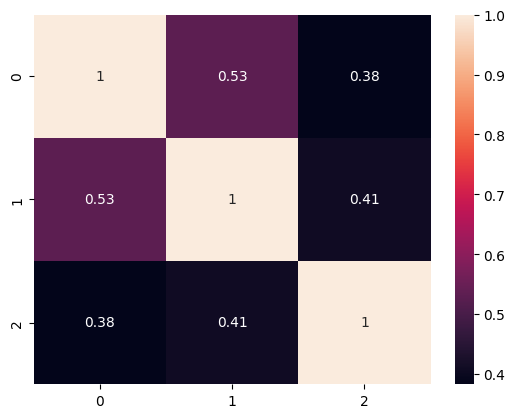

In [15]:
import seaborn as sns
sns.heatmap(similarity_matrix, annot=True)

## Semantic Job–Resume Matching System

Used in:
- ATS
- Recruitment platforms
- Talent screening

Instead of keyword matching, we compare **meaning**.


In [26]:
job_description = "Looking for a machine learning engineer with Python experience"
resume = "machine learning engineer with strong Python and AI background"

job_embedding = embedding_model.encode([job_description])
resume_embedding = embedding_model.encode([resume])

similarity_score = cosine_similarity(job_embedding, resume_embedding)

print("Semantic Match Score:", similarity_score[0][0])


Semantic Match Score: 0.74935174


## Semantic Search Engine

Steps:
1. Convert documents to embeddings
2. Store vectors
3. Convert query to embedding
4. Find closest vectors

This powers:
- Document search
- Resume ranking
- Contract retrieval


In [29]:
documents = [
    "Python machine learning engineer",
    "Senior accountant with finance experience",
    "Legal advisor for corporate contracts"
]

doc_embeddings = embedding_model.encode(documents)

query = "AI developer with Python"
query_embedding = embedding_model.encode([query])

scores = cosine_similarity(query_embedding, doc_embeddings)

for doc, score in zip(documents, scores[0]):
    print(doc, "->", score)
# scores

Python machine learning engineer -> 0.705891
Senior accountant with finance experience -> 0.13282008
Legal advisor for corporate contracts -> 0.1989232


## Fine-Tuning NER Models

Fine-tuning is required when:
- Custom entity types are needed
- Domain-specific language exists (medical, legal)

Steps:
1. Label data (BIO format)
2. Tokenize text
3. Train transformer
4. Evaluate and deploy

(Hands-on fine-tuning covered in advanced sessions)


## Industry Use Cases

| Industry | Application |
|--------|-------------|
| HR | Resume parsing, ATS |
| Legal | Contract analysis |
| FinTech | Invoice extraction |
| Healthcare | Clinical entity recognition |


## Assignment

1. Parse a resume and extract entities (single landing page to upload file.)
2. Build a job–resume matcher
3. Add 5 resumes and rank them
4. Write conclusion:
   **Why semantic search beats keyword search**

